# Whitened Residual PCA Diagnostics for Real-data Corridor Vecchia

This notebook repeats the one-day corridor-width 4x4 lag432 setup, but performs PCA/SVD on **Vecchia Cholesky-whitened residuals** rather than raw residual fields.

Why this is different from the raw residual PCA notebook:

- raw residual PCA checks whether the mean design leaves large coherent residual fields;
- whitened residual PCA checks whether the fitted mean **and covariance/Vecchia conditional model** remove the structure that the likelihood says should be explained.

If the model is close, the whitened residual fields should look much less dominated by one spatial component.


In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')

import sys, time, gc, contextlib, io
import numpy as np
import pandas as pd
import torch
from torch.nn import Parameter
import matplotlib.pyplot as plt

sys.path.insert(0, '/Users/joonwonlee/Documents/GEMS_TCO-1/src')

from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO.vecchia_realdata_corridor_width_4x4_lag432 import (
    BLOCK_SHAPE,
    LAG_COUNTS,
    REFERENCE_ADVEC_LON_ABS,
    SPEC_NAME as VECCHIA_SPEC_NAME,
    build_model as build_corridor_width_432_model,
    model_spec as corridor_width_432_spec,
)

pd.set_option('display.max_columns', 140)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.dpi'] = 180

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())


torch: 2.5.1
cuda available: False


In [2]:
YEAR = '2024'
MONTH = 7
DAYS_LIST = [13]  # 0-based day index: July 14, 2024. One model day = 8 time slots.
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]
LAT_LON_RESOLUTION = [1, 1]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.double
SMOOTH = 0.5
DAILY_STRIDE = 2

OUT_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/space_time/vecchia_cluster_batch/diagnostics')
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PREFIX = 'whitened_pca_detrend_corridor_20240714_lag432'
RAW_DIAG_PREFIX = 'pca_detrend_corridor_20240714_lag432'
CACHED_FIT_SUMMARY = OUT_DIR / f'{RAW_DIAG_PREFIX}_fit_summary.csv'
USE_CACHED_FIT_IF_AVAILABLE = True

REFERENCE_ADVEC_LON_ABS = 0.126
MODEL_SPEC = corridor_width_432_spec(REFERENCE_ADVEC_LON_ABS)
TARGET_CHUNK_SIZE = 96

LBFGS_LR = 1.0
LBFGS_MAX_STEPS = 5
LBFGS_MAX_EVAL = 20
LBFGS_HISTORY_SIZE = 10
GRAD_TOL = 1e-5
SUPPRESS_FIT_PRINTS = False

INIT_PHYSICAL = {
    'sigmasq': 10.0,
    'range_lat': 0.30,
    'range_lon': 0.40,
    'range_time': 2.0,
    'advec_lat': 0.05,
    'advec_lon': -0.10,
    'nugget': 2.5,
}

DESIGNS = ['hour_lat', 'hour_latlon', 'hour_quadratic', 'hour_spatial']
ROUND_DECIMALS = 5

print('device:', DEVICE)
print('days:', DAYS_LIST)
print('spec:', VECCHIA_SPEC_NAME)
print('model spec:', MODEL_SPEC)
print('cached fit summary:', CACHED_FIT_SUMMARY, 'exists=', CACHED_FIT_SUMMARY.exists())


device: cpu
days: [13]
spec: corridor_width_4x4_lag432_delta0p126
model spec: {'spec_name': 'corridor_width_4x4_lag432_delta0p126', 'strategy': 'offset_corridor_tapered', 'conditioning_mode': 'corridor_width_light', 'block_shape': (4, 4), 'lag_counts': (4, 3, 2), 'lag_pattern': '4/3/2', 'reference_advec_lon_abs': 0.126, 'lag1_lon_offset': 0.126, 'lag2_lon_offset': 0.252, 'lag1_lon_interval': (0.063, 0.189), 'lag2_lon_interval': (0.0, 0.252), 'corridor_anchor_mode': 'width'}
cached fit summary: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/space_time/vecchia_cluster_batch/diagnostics/pca_detrend_corridor_20240714_lag432_fit_summary.csv exists= True


In [3]:
def round_numeric_df(df, digits=ROUND_DECIMALS):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)
    return out


def round_numeric_series(s, digits=ROUND_DECIMALS):
    out = s.copy()
    for idx, val in out.items():
        if isinstance(val, (float, np.floating)) and np.isfinite(val):
            out[idx] = round(float(val), digits)
    return out


P_LABELS = ['sigmasq', 'range_lat', 'range_lon', 'range_time', 'advec_lat', 'advec_lon', 'nugget']


def physical_to_log_phi(params):
    sigmasq = float(params['sigmasq'])
    range_lat = float(params['range_lat'])
    range_lon = float(params['range_lon'])
    range_time = float(params['range_time'])
    nugget = float(params['nugget'])
    phi2 = 1.0 / range_lon
    phi1 = sigmasq * phi2
    phi3 = (range_lon / range_lat) ** 2
    phi4 = (range_lon / range_time) ** 2
    return [
        np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
        float(params['advec_lat']), float(params['advec_lon']), np.log(nugget),
    ]


def backmap_params(out_params):
    p = [x.item() if isinstance(x, torch.Tensor) else float(x) for x in out_params[:7]]
    phi2 = np.exp(p[1])
    phi3 = np.exp(p[2])
    phi4 = np.exp(p[3])
    rlon = 1.0 / phi2
    return {
        'sigmasq': np.exp(p[0]) / phi2,
        'range_lat': rlon / phi3 ** 0.5,
        'range_lon': rlon,
        'range_time': rlon / phi4 ** 0.5,
        'advec_lat': p[4],
        'advec_lon': p[5],
        'nugget': np.exp(p[6]),
    }


def make_params_list(init_physical=INIT_PHYSICAL):
    initial_vals = physical_to_log_phi(init_physical)
    return [Parameter(torch.tensor([val], dtype=DTYPE, device=DEVICE)) for val in initial_vals]


def fitted_params_from_summary(path):
    df = pd.read_csv(path)
    row = df.iloc[0]
    physical = {
        'sigmasq': row['est_sigmasq'],
        'range_lat': row['est_range_lat'],
        'range_lon': row['est_range_lon'],
        'range_time': row['est_range_time'],
        'advec_lat': row['est_advec_lat'],
        'advec_lon': row['est_advec_lon'],
        'nugget': row['est_nugget'],
    }
    raw = physical_to_log_phi(physical)
    return torch.tensor(raw, dtype=torch.float64, device=DEVICE), physical

print('init log phi:', np.round(physical_to_log_phi(INIT_PHYSICAL), 4))


init log phi: [ 3.2189  0.9163  0.5754 -3.2189  0.05   -0.1     0.9163]


## Load one model day

The data-loading path mirrors the reference corridor notebook. We use exact source coordinates in the model tensors and regular grid coordinates for cluster construction.


In [4]:
data_load_instance = load_data_dynamic_processed(config.mac_data_load_path)

df_map, _, _, monthly_mean = data_load_instance.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=LAT_LON_RESOLUTION,
    mm_cond_number=1,
    years_=[YEAR],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=True,
)

key_idx = sorted(df_map)
print('n hourly slots:', len(key_idx))
print('monthly_mean:', monthly_mean)
print('first key:', key_idx[0], 'last key:', key_idx[-1])

base_grid_coords_np = df_map[key_idx[0]][['Latitude', 'Longitude']].to_numpy(dtype=np.float64)
print('base_grid_coords_np:', base_grid_coords_np.shape)
print('n unique lat/lon:', len(np.unique(base_grid_coords_np[:, 0])), len(np.unique(base_grid_coords_np[:, 1])))


--- Global Monthly Mean for 2024-7: 257.9726 ---
n hourly slots: 248
monthly_mean: 257.9726104252314
first key: 2024_07_y24m07day01_hm00:53 last key: 2024_07_y24m07day31_hm07:48
base_grid_coords_np: (18126, 2)
n unique lat/lon: 114 159


In [5]:
def assert_grid_order_consistent(keys, base_coords):
    for k in keys:
        coords = df_map[k][['Latitude', 'Longitude']].to_numpy(dtype=np.float64)
        if coords.shape != base_coords.shape or not np.allclose(coords, base_coords, equal_nan=True):
            raise RuntimeError(f'Grid coordinate order differs at {k}; cluster local-index mapping is not reusable.')


for day_idx in DAYS_LIST:
    hour_indices = [day_idx * 8, (day_idx + 1) * 8]
    assert_grid_order_consistent(key_idx[hour_indices[0]:hour_indices[1]], base_grid_coords_np)
print('grid order consistency check passed for selected days')


grid order consistency check passed for selected days


In [6]:
daily_hourly_maps = {}
selected_key_map = {}

for day_idx in DAYS_LIST:
    hour_indices = [day_idx * 8, (day_idx + 1) * 8]
    selected_key_map[day_idx] = key_idx[hour_indices[0]:hour_indices[1]]
    day_hourly_map, _ = data_load_instance.load_working_data(
        df_map,
        monthly_mean,
        hour_indices,
        ord_mm=None,
        dtype=DTYPE,
        keep_ori=True,
    )
    daily_hourly_maps[day_idx] = {k: v.to(DEVICE) for k, v in day_hourly_map.items()}

rows = []
for day_idx, maps in daily_hourly_maps.items():
    n_valid = sum(int((~torch.isnan(v[:, 2])).sum().item()) for v in maps.values())
    n_total = sum(int(v.shape[0]) for v in maps.values())
    rows.append({
        'day_idx': day_idx,
        'day': f'{YEAR}-{MONTH:02d}-{day_idx + 1:02d}',
        'n_time_slots': len(maps),
        'n_grid': int(next(iter(maps.values())).shape[0]),
        'n_rows_total': n_total,
        'n_valid_o3': n_valid,
        'valid_rate': n_valid / n_total,
        'first_slot': selected_key_map[day_idx][0],
        'last_slot': selected_key_map[day_idx][-1],
    })
load_summary = pd.DataFrame(rows)
display(round_numeric_df(load_summary))


,day_idx,day,n_time_slots,n_grid,n_rows_total,n_valid_o3,valid_rate,first_slot,last_slot
0,13,2024-07-14,8,18126,145008,144078,0.9936,2024_07_y24m07day14_hm00:53,2024_07_y24m07day14_hm07:48


## Instantiate/precompute the reference model and get fitted covariance

If the raw residual diagnostic notebook has already produced a fit summary, this notebook reuses those fitted covariance parameters. Otherwise it runs the same lightweight one-day fit.


In [7]:
def instantiate_model(day_map):
    return build_corridor_width_432_model(
        smooth=SMOOTH,
        input_map=day_map,
        grid_coords=base_grid_coords_np,
        reference_advec_lon_abs=REFERENCE_ADVEC_LON_ABS,
        daily_stride=DAILY_STRIDE,
        target_chunk_size=TARGET_CHUNK_SIZE,
    )


def fit_reference_model(model):
    params_list = make_params_list()
    optimizer = model.set_optimizer(
        params_list,
        lr=LBFGS_LR,
        max_iter=LBFGS_MAX_EVAL,
        max_eval=LBFGS_MAX_EVAL,
        history_size=LBFGS_HISTORY_SIZE,
    )
    t1 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            out, steps_ran = model.fit_vecc_lbfgs(params_list, optimizer, max_steps=LBFGS_MAX_STEPS, grad_tol=GRAD_TOL)
    else:
        out, steps_ran = model.fit_vecc_lbfgs(params_list, optimizer, max_steps=LBFGS_MAX_STEPS, grad_tol=GRAD_TOL)
    fit_s = time.time() - t1
    return torch.tensor(out[:7], dtype=torch.float64, device=DEVICE), out, int(steps_ran), fit_s


DAY_IDX = DAYS_LIST[0]
day_map = daily_hourly_maps[DAY_IDX]
model = instantiate_model(day_map)

t0 = time.time()
if SUPPRESS_FIT_PRINTS:
    with contextlib.redirect_stdout(io.StringIO()):
        model.precompute_conditioning_sets()
else:
    model.precompute_conditioning_sets()
precompute_s = time.time() - t0

if USE_CACHED_FIT_IF_AVAILABLE and CACHED_FIT_SUMMARY.exists():
    fitted_params, cached_physical = fitted_params_from_summary(CACHED_FIT_SUMMARY)
    fit_source = 'cached_fit_summary'
    fit_loss = float(pd.read_csv(CACHED_FIT_SUMMARY).iloc[0]['loss'])
    steps_ran = np.nan
    fit_s = 0.0
else:
    fitted_params, out, steps_ran, fit_s = fit_reference_model(model)
    cached_physical = backmap_params(out)
    fit_source = 'refit_in_this_notebook'
    fit_loss = float(out[-1])

fit_row = {
    'day_idx': DAY_IDX,
    'day': f'{YEAR}-{MONTH:02d}-{DAY_IDX + 1:02d}',
    'fit_source': fit_source,
    'smooth': SMOOTH,
    'spec_name': VECCHIA_SPEC_NAME,
    'block_shape': f'{BLOCK_SHAPE[0]}x{BLOCK_SHAPE[1]}',
    'lag_pattern': MODEL_SPEC['lag_pattern'],
    'loss_from_fit_source': fit_loss,
    'steps_raw': steps_ran,
    'precompute_s': precompute_s,
    'fit_s': fit_s,
    **{f'est_{k}': float(cached_physical[k]) for k in P_LABELS},
    **model.cluster_summary(),
}
fit_summary = pd.DataFrame([fit_row])
display(round_numeric_df(fit_summary))
fit_summary.to_csv(OUT_DIR / f'{OUT_PREFIX}_fit_summary.csv', index=False)


Pre-computing StrategyClusterVecchia (smooth=0.5, strategy=offset_corridor_tapered, block=(4, 4), origin=0/0, lag_blocks=4/3/2, basis=corridor, force_center=0, offsets=0.1260/0.2520, corridors=(0.063, 0.189)/(0.0, 0.252), anchor_mode=width)... 

Done. clusters=1160, max_points/block=16, target_blocks=9278, target_points=144078, batches=[A:m64:b6x1, A:m64:b8x53, A:m64:b11x2, A:m64:b12x12, A:m64:b16x1092, AB:m112:b2x1, AB:m112:b7x1, AB:m112:b8x50, AB:m112:b11x2, AB:m112:b12x14, ... (26 batches)]


,day_idx,day,fit_source,smooth,spec_name,block_shape,lag_pattern,loss_from_fit_source,steps_raw,precompute_s,fit_s,est_sigmasq,est_range_lat,est_range_lon,est_range_time,est_advec_lat,est_advec_lon,est_nugget,n_clusters,block_shape_lat,block_shape_lon,max_points_per_cluster,n_target_blocks,n_target_points,n_batches,target_chunk_size,strategy,temporal_basis,force_target_center,lag0_block_count,lag1_block_count,lag2_block_count,lag1_max_blocks,lag2_max_blocks,lag1_lon_offset,lag2_lon_offset,lag1_lon_interval_lo,lag1_lon_interval_hi,lag2_lon_interval_lo,lag2_lon_interval_hi,corridor_anchor_mode,grid_lon_step,corridor_block_lon_width,block_row_offset,block_col_offset
0,13,2024-07-14,cached_fit_summary,0.5,corridor_width_4x4_lag432_delta0p126,4x4,4/3/2,1.0696,NaN,0.9534,0.0,7.7808,0.2299,0.2809,1.4183,0.0047,-0.0375,1.1224,1160,4,4,16,9278,144078,26,96,offset_corridor_tapered,corridor,0,4,3,2,3,2,0.126,0.252,0.063,0.189,0.0,0.252,width,0.063,0.252,0,0


## Mean-design and GLS helpers

The GLS beta for each design is estimated in the same whitened space used by the Vecchia likelihood, with covariance fixed at the fitted parameter values.


In [8]:
def observed_coord_means(day_map):
    rows = torch.cat([v.detach().cpu() for v in day_map.values()], dim=0).numpy()
    ok = np.isfinite(rows[:, 2]) & np.isfinite(rows[:, 0]) & np.isfinite(rows[:, 1])
    return float(rows[ok, 0].mean()), float(rows[ok, 1].mean())


lat_mean_data, lon_mean_data = observed_coord_means(day_map)
print('model.lat_mean_val:', float(model.lat_mean_val))
print('data means lat/lon:', lat_mean_data, lon_mean_data)


def feature_names(design):
    dummies = [f'D{k}' for k in range(1, 8)]
    if design == 'hour_lat':
        return ['intercept', 'lat_c'] + dummies
    if design == 'hour_latlon':
        return ['intercept', 'lat_c', 'lon_c'] + dummies
    if design == 'hour_quadratic':
        return ['intercept', 'lat_c', 'lon_c', 'lat_c2', 'lat_lon_c', 'lon_c2'] + dummies
    if design == 'hour_spatial':
        hours = [f'H{k}' for k in range(8)]
        return hours + [f'{h}:lat_c' for h in hours] + [f'{h}:lon_c' for h in hours]
    raise ValueError(f'unknown design: {design}')


def _pad_dummies(dums):
    width = dums.shape[-1]
    if width >= 7:
        return dums[..., :7]
    pad = torch.zeros((*dums.shape[:-1], 7 - width), device=dums.device, dtype=dums.dtype)
    return torch.cat([dums, pad], dim=-1)


def design_from_batch(model, batch, design, lon_mean):
    lat_mean = float(model.lat_mean_val)
    coords = batch.X.to(torch.float64)
    lat = coords[..., 0:1] - lat_mean
    lon = coords[..., 1:2] - float(lon_mean)
    ones = torch.ones_like(lat)
    dums = _pad_dummies(batch.Locs[..., 2:9].to(torch.float64))

    if design == 'hour_lat':
        X = torch.cat([ones, lat, dums], dim=-1)
    elif design == 'hour_latlon':
        X = torch.cat([ones, lat, lon, dums], dim=-1)
    elif design == 'hour_quadratic':
        X = torch.cat([ones, lat, lon, lat.pow(2), lat * lon, lon.pow(2), dums], dim=-1)
    elif design == 'hour_spatial':
        first_hour = (1.0 - dums.sum(dim=-1, keepdim=True)).clamp(min=0.0, max=1.0)
        hour_onehot = torch.cat([first_hour, dums], dim=-1)
        X = torch.cat([hour_onehot, hour_onehot * lat, hour_onehot * lon], dim=-1)
    else:
        raise ValueError(f'unknown design: {design}')

    return X.masked_fill(batch.is_dummy, 0.0).contiguous()


def gls_beta_for_design(model, params, design, lon_mean, jitter=1e-6):
    p = len(feature_names(design))
    xt_sinv_x = torch.zeros((p, p), device=model.device, dtype=torch.float64)
    xt_sinv_y = torch.zeros((p, 1), device=model.device, dtype=torch.float64)
    y_sinv_y = torch.tensor(0.0, device=model.device, dtype=torch.float64)
    log_det = torch.tensor(0.0, device=model.device, dtype=torch.float64)
    total_n = 0

    chunk_size = max(1, int(model.target_chunk_size))
    with torch.no_grad():
        for batch in model._cluster_batches:
            if batch.X.shape[0] == 0:
                continue
            locs_all = design_from_batch(model, batch, design, lon_mean)
            target_slice = slice(batch.max_cond_points, batch.max_cond_points + batch.target_size)
            for start in range(0, batch.X.shape[0], chunk_size):
                end = min(start + chunk_size, batch.X.shape[0])
                cov_chunk = model.matern_cov_batched(params, batch.X[start:end])
                L_chunk = torch.linalg.cholesky(cov_chunk)
                z_locs = torch.linalg.solve_triangular(L_chunk, locs_all[start:end], upper=False)
                z_y = torch.linalg.solve_triangular(L_chunk, batch.Y[start:end], upper=False)

                u_x = z_locs[:, target_slice, :].reshape(-1, p)
                u_y = z_y[:, target_slice, :].reshape(-1, 1)
                diag_l = torch.diagonal(L_chunk, dim1=1, dim2=2)[:, target_slice]

                xt_sinv_x += u_x.T @ u_x
                xt_sinv_y += u_x.T @ u_y
                y_sinv_y += (u_y.T @ u_y).squeeze()
                log_det += 2.0 * torch.sum(torch.log(diag_l))
                total_n += int(u_y.shape[0])

        beta = torch.linalg.solve(xt_sinv_x + torch.eye(p, device=model.device, dtype=torch.float64) * jitter, xt_sinv_y)
        quad = y_sinv_y - 2.0 * (beta.T @ xt_sinv_y).squeeze() + (beta.T @ xt_sinv_x @ beta).squeeze()
        nll = 0.5 * (log_det + quad) / max(total_n, 1)
    return beta, float(nll.detach().cpu().item()), int(total_n)


model.lat_mean_val: -0.4802863299846649
data means lat/lon: -0.4802863451661079 126.0133083267258


## Extract target-indexed whitened residual fields

For each cluster batch, the likelihood computes `L^{-1}Y` and `L^{-1}X` for the conditioning+target block and then keeps the target rows. We reconstruct those target rows and place them back into an 8-by-grid residual matrix.


In [9]:
def whitened_residual_matrix_for_design(model, params, design, beta, lon_mean, n_time, n_grid):
    W = np.full((n_time, n_grid), np.nan, dtype=np.float64)
    duplicate_count = 0
    assign_count = 0
    chunk_size = max(1, int(model.target_chunk_size))

    with torch.no_grad():
        for batch in model._cluster_batches:
            if batch.X.shape[0] == 0:
                continue
            locs_all = design_from_batch(model, batch, design, lon_mean)
            target_slice = slice(batch.max_cond_points, batch.max_cond_points + batch.target_size)
            for start in range(0, batch.X.shape[0], chunk_size):
                end = min(start + chunk_size, batch.X.shape[0])
                cov_chunk = model.matern_cov_batched(params, batch.X[start:end])
                L_chunk = torch.linalg.cholesky(cov_chunk)
                z_locs = torch.linalg.solve_triangular(L_chunk, locs_all[start:end], upper=False)
                z_y = torch.linalg.solve_triangular(L_chunk, batch.Y[start:end], upper=False)
                pred = torch.matmul(z_locs[:, target_slice, :], beta).squeeze(-1)
                resid = (z_y[:, target_slice, 0] - pred).detach().cpu().numpy()
                target_global = batch.T[start:end, target_slice].detach().cpu().numpy()

                flat_idx = target_global.reshape(-1)
                flat_resid = resid.reshape(-1)
                real_ok = flat_idx < (n_time * n_grid)
                time_idx = flat_idx[real_ok] // n_grid
                point_idx = flat_idx[real_ok] % n_grid
                vals = flat_resid[real_ok]

                already = np.isfinite(W[time_idx, point_idx])
                duplicate_count += int(already.sum())
                W[time_idx, point_idx] = vals
                assign_count += int(vals.size)

    return W, {'assigned': assign_count, 'duplicates': duplicate_count, 'finite': int(np.isfinite(W).sum())}


def residual_moments(x):
    z = np.asarray(x, dtype=np.float64)
    z = z[np.isfinite(z)]
    if z.size == 0:
        return {'mean': np.nan, 'sd': np.nan, 'rmse': np.nan, 'mae': np.nan, 'skew': np.nan, 'excess_kurtosis': np.nan}
    mu = z.mean()
    sd = z.std(ddof=0)
    centered = z - mu
    skew = np.mean(centered ** 3) / (sd ** 3) if sd > 0 else np.nan
    ex_kurt = np.mean(centered ** 4) / (sd ** 4) - 3.0 if sd > 0 else np.nan
    return {
        'mean': float(mu),
        'sd': float(sd),
        'rmse': float(np.sqrt(np.mean(z ** 2))),
        'mae': float(np.mean(np.abs(z))),
        'skew': float(skew),
        'excess_kurtosis': float(ex_kurt),
    }


diagnostics = {}
summary_rows = []
beta_tables = []
n_time = len(day_map)
n_grid = int(next(iter(day_map.values())).shape[0])

for design in DESIGNS:
    print(f'--- GLS beta and whitened target residuals for {design} ---')
    beta, fixed_cov_nll, total_n = gls_beta_for_design(model, fitted_params, design, lon_mean_data)
    W, assign_info = whitened_residual_matrix_for_design(
        model, fitted_params, design, beta, lon_mean_data, n_time=n_time, n_grid=n_grid
    )
    moments = residual_moments(W)
    diagnostics[design] = {
        'beta': beta.detach().cpu().numpy().reshape(-1),
        'fixed_cov_nll': fixed_cov_nll,
        'total_n': total_n,
        'whitened_matrix': W,
        'assign_info': assign_info,
    }
    summary_rows.append({
        'design': design,
        'n_features': len(feature_names(design)),
        'fixed_cov_nll': fixed_cov_nll,
        'total_n': total_n,
        'assigned': assign_info['assigned'],
        'duplicates': assign_info['duplicates'],
        'finite': assign_info['finite'],
        'finite_rate': float(np.isfinite(W).mean()),
        **{f'wresid_{k}': v for k, v in moments.items()},
    })
    beta_tables.append(pd.DataFrame({
        'design': design,
        'feature': feature_names(design),
        'beta': diagnostics[design]['beta'],
    }))

raw_summary_df = pd.DataFrame(summary_rows)
beta_df = pd.concat(beta_tables, ignore_index=True)
display(round_numeric_df(raw_summary_df))
raw_summary_df.to_csv(OUT_DIR / f'{OUT_PREFIX}_whitened_residual_summary.csv', index=False)
beta_df.to_csv(OUT_DIR / f'{OUT_PREFIX}_gls_betas.csv', index=False)


--- GLS beta and whitened target residuals for hour_lat ---


--- GLS beta and whitened target residuals for hour_latlon ---


--- GLS beta and whitened target residuals for hour_quadratic ---


--- GLS beta and whitened target residuals for hour_spatial ---


,design,n_features,fixed_cov_nll,total_n,assigned,duplicates,finite,finite_rate,wresid_mean,wresid_sd,wresid_rmse,wresid_mae,wresid_skew,wresid_excess_kurtosis
0,hour_lat,9,1.0696,144078,144078,0,144078,0.9936,-0.0048,1.0000,1.0000,0.7032,4.0494,270.5886
1,hour_latlon,10,1.0694,144078,144078,0,144078,0.9936,-0.0046,0.9998,0.9998,0.7026,4.0617,270.8484
2,hour_quadratic,13,1.0691,144078,144078,0,144078,0.9936,-0.0042,0.9994,0.9994,0.7022,4.0647,271.2283
3,hour_spatial,24,1.0691,144078,144078,0,144078,0.9936,-0.0046,0.9994,0.9995,0.7022,4.0709,271.1486


## PCA/SVD on whitened residual fields

The matrix is time slots by grid cells. Each row's scalar mean is removed before SVD. Under an ideal whitened model, no single spatial component should dominate the energy, and PC loadings should not align strongly with simple spatial polynomial bases.


In [10]:
def spatial_svd(resid_mat, n_components=4):
    valid_mask = np.isfinite(resid_mat).all(axis=0)
    R = resid_mat[:, valid_mask].astype(np.float64)
    R0 = R - R.mean(axis=1, keepdims=True)
    U, S, Vt = np.linalg.svd(R0, full_matrices=False)
    power = S ** 2
    explained = power / power.sum() if power.sum() > 0 else np.full_like(power, np.nan)
    n = min(n_components, Vt.shape[0])
    return {
        'valid_mask': valid_mask,
        'scores': U[:, :n] * S[:n],
        'components': Vt[:n, :],
        'singular_values': S[:n],
        'explained': explained[:n],
        'slot_means': R.mean(axis=1),
    }


def corr2(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 3 or np.nanstd(a[ok]) == 0 or np.nanstd(b[ok]) == 0:
        return np.nan
    return float(np.corrcoef(a[ok], b[ok])[0, 1] ** 2)


def linear_r2(y, X):
    y = np.asarray(y, dtype=np.float64)
    X = np.asarray(X, dtype=np.float64)
    ok = np.isfinite(y) & np.isfinite(X).all(axis=1)
    if ok.sum() <= X.shape[1] + 1:
        return np.nan
    yy = y[ok]
    XX = np.column_stack([np.ones(ok.sum()), X[ok]])
    coef, *_ = np.linalg.lstsq(XX, yy, rcond=None)
    fitted = XX @ coef
    sse = np.sum((yy - fitted) ** 2)
    sst = np.sum((yy - yy.mean()) ** 2)
    return float(1.0 - sse / sst) if sst > 0 else np.nan


def poly_basis_for_coords(coords, lat_center, lon_center):
    lat = coords[:, 0] - float(lat_center)
    lon = coords[:, 1] - float(lon_center)
    return pd.DataFrame({
        'lat_c': lat,
        'lon_c': lon,
        'lat_c2': lat ** 2,
        'lat_lon_c': lat * lon,
        'lon_c2': lon ** 2,
    })


svd_rows = []
align_rows = []
poly_basis_all = poly_basis_for_coords(base_grid_coords_np, float(model.lat_mean_val), lon_mean_data)

for design in DESIGNS:
    svd = spatial_svd(diagnostics[design]['whitened_matrix'])
    diagnostics[design]['svd'] = svd
    valid = svd['valid_mask']
    basis_valid = poly_basis_all.loc[valid].reset_index(drop=True)

    # Orient components by positive latitude correlation for easier visual comparison.
    for k in range(svd['components'].shape[0]):
        c = np.corrcoef(svd['components'][k], basis_valid['lat_c'])[0, 1]
        if np.isfinite(c) and c < 0:
            svd['components'][k] *= -1.0
            svd['scores'][:, k] *= -1.0

    mean_wresid = np.nanmean(diagnostics[design]['whitened_matrix'], axis=0)
    svd_rows.append({
        'design': design,
        'n_complete_grid': int(valid.sum()),
        'slot_mean_sd': float(np.nanstd(svd['slot_means'])),
        'pc1_share': float(svd['explained'][0]) if len(svd['explained']) > 0 else np.nan,
        'pc2_share': float(svd['explained'][1]) if len(svd['explained']) > 1 else np.nan,
        'pc3_share': float(svd['explained'][2]) if len(svd['explained']) > 2 else np.nan,
        'pc4_share': float(svd['explained'][3]) if len(svd['explained']) > 3 else np.nan,
        'pc1_poly5_r2': linear_r2(svd['components'][0], basis_valid.to_numpy()),
        'mean_wresid_poly5_r2': linear_r2(mean_wresid[valid], basis_valid.to_numpy()),
    })

    for pc_idx in range(min(2, svd['components'].shape[0])):
        comp = svd['components'][pc_idx]
        row = {
            'design': design,
            'component': f'PC{pc_idx + 1}',
            'poly5_r2': linear_r2(comp, basis_valid.to_numpy()),
        }
        for col in basis_valid.columns:
            row[f'{col}_corr2'] = corr2(comp, basis_valid[col])
        align_rows.append(row)

svd_summary_df = pd.DataFrame(svd_rows)
alignment_df = pd.DataFrame(align_rows)
summary_df = raw_summary_df.merge(svd_summary_df, on='design', how='left')
display(round_numeric_df(summary_df))
display(round_numeric_df(alignment_df))
summary_df.to_csv(OUT_DIR / f'{OUT_PREFIX}_pca_summary.csv', index=False)
alignment_df.to_csv(OUT_DIR / f'{OUT_PREFIX}_pc_poly_alignment.csv', index=False)


,design,n_features,fixed_cov_nll,total_n,assigned,duplicates,finite,finite_rate,wresid_mean,wresid_sd,wresid_rmse,wresid_mae,wresid_skew,wresid_excess_kurtosis,n_complete_grid,slot_mean_sd,pc1_share,pc2_share,pc3_share,pc4_share,pc1_poly5_r2,mean_wresid_poly5_r2
0,hour_lat,9,1.0696,144078,144078,0,144078,0.9936,-0.0048,1.0000,1.0000,0.7032,4.0494,270.5886,17529,0.0101,0.1716,0.1436,0.1288,0.1233,0.0047,0.0053
1,hour_latlon,10,1.0694,144078,144078,0,144078,0.9936,-0.0046,0.9998,0.9998,0.7026,4.0617,270.8484,17529,0.0102,0.1712,0.1436,0.1288,0.1234,0.0026,0.0028
2,hour_quadratic,13,1.0691,144078,144078,0,144078,0.9936,-0.0042,0.9994,0.9994,0.7022,4.0647,271.2283,17529,0.0101,0.1712,0.1437,0.1288,0.1235,0.0027,0.0028
3,hour_spatial,24,1.0691,144078,144078,0,144078,0.9936,-0.0046,0.9994,0.9995,0.7022,4.0709,271.1486,17529,0.0103,0.1711,0.1436,0.1289,0.1234,0.0015,0.0019


,design,component,poly5_r2,lat_c_corr2,lon_c_corr2,lat_c2_corr2,lat_lon_c_corr2,lon_c2_corr2
0,hour_lat,PC1,0.0047,0.0000,0.0041,0.0002,0.0002,0.0002
1,hour_lat,PC2,0.0007,0.0000,0.0003,0.0003,0.0000,0.0000
2,hour_latlon,PC1,0.0026,0.0000,0.0020,0.0002,0.0002,0.0002
3,hour_latlon,PC2,0.0006,0.0000,0.0002,0.0003,0.0000,0.0000
4,hour_quadratic,PC1,0.0027,0.0000,0.0021,0.0001,0.0001,0.0003
5,hour_quadratic,PC2,0.0006,0.0001,0.0002,0.0002,0.0001,0.0000
6,hour_spatial,PC1,0.0015,0.0001,0.0009,0.0002,0.0002,0.0002
7,hour_spatial,PC2,0.0004,0.0001,0.0000,0.0003,0.0000,0.0000


## Visual diagnostics

These are the whitened analogues of the raw residual plots.


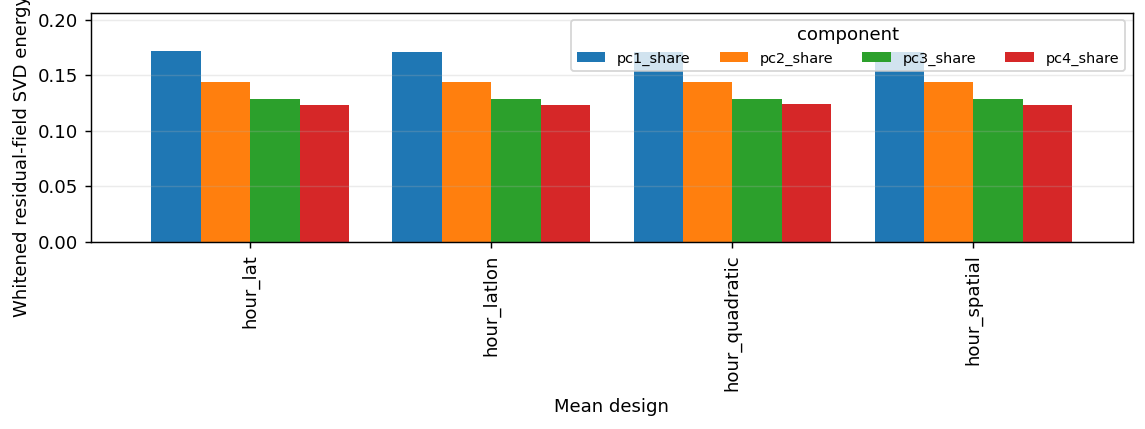

In [11]:
def full_grid_values(valid_mask, values):
    out = np.full(valid_mask.shape[0], np.nan, dtype=np.float64)
    out[valid_mask] = values
    return out


def symmetric_quantile(values, q=0.995, fallback=1.0):
    arr = np.asarray(values, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return fallback
    vmax = float(np.nanquantile(np.abs(arr), q))
    return vmax if vmax > 0 else fallback


def scatter_spatial(ax, values, title, cmap='coolwarm', vmax=None, size=4):
    lat = base_grid_coords_np[:, 0]
    lon = base_grid_coords_np[:, 1]
    if vmax is None:
        vmax = symmetric_quantile(values)
    sc = ax.scatter(lon, lat, c=values, s=size, cmap=cmap, vmin=-vmax, vmax=vmax, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal', adjustable='box')
    return sc


plot_df = summary_df.set_index('design')[[f'pc{k}_share' for k in range(1, 5)]].copy()
fig, ax = plt.subplots(figsize=(9, 3.4))
plot_df.plot(kind='bar', ax=ax, width=0.82)
ax.set_ylabel('Whitened residual-field SVD energy share')
ax.set_xlabel('Mean design')
ax.set_ylim(0, min(1.0, max(0.1, np.nanmax(plot_df.to_numpy()) * 1.2)))
ax.legend(title='component', ncols=4, fontsize=8)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / f'{OUT_PREFIX}_scree_bar.png')
plt.show()


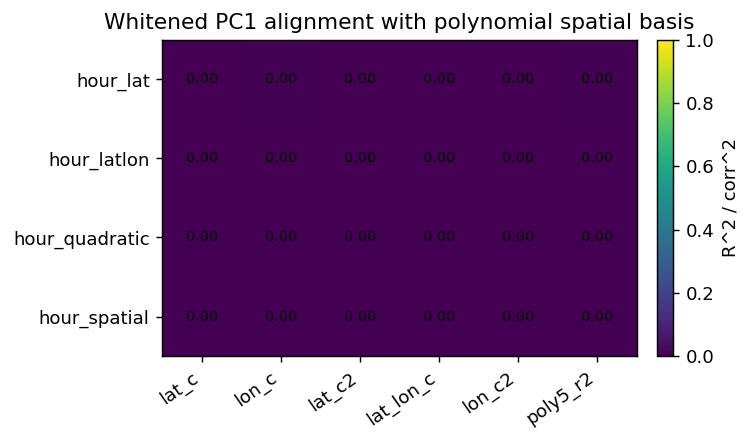

In [12]:
heat = alignment_df[alignment_df['component'] == 'PC1'].set_index('design')[[
    'lat_c_corr2', 'lon_c_corr2', 'lat_c2_corr2', 'lat_lon_c_corr2', 'lon_c2_corr2', 'poly5_r2'
]]
fig, ax = plt.subplots(figsize=(8.5, 3.5))
im = ax.imshow(heat.to_numpy(), vmin=0, vmax=1, cmap='viridis')
ax.set_xticks(np.arange(heat.shape[1]))
ax.set_xticklabels([c.replace('_corr2', '') for c in heat.columns], rotation=35, ha='right')
ax.set_yticks(np.arange(heat.shape[0]))
ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        ax.text(j, i, f'{val:.2f}' if np.isfinite(val) else 'NA', ha='center', va='center', fontsize=8,
                color='white' if np.isfinite(val) and val > 0.55 else 'black')
ax.set_title('Whitened PC1 alignment with polynomial spatial basis')
fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02, label='R^2 / corr^2')
fig.tight_layout()
fig.savefig(OUT_DIR / f'{OUT_PREFIX}_pc1_poly_alignment_heatmap.png')
plt.show()


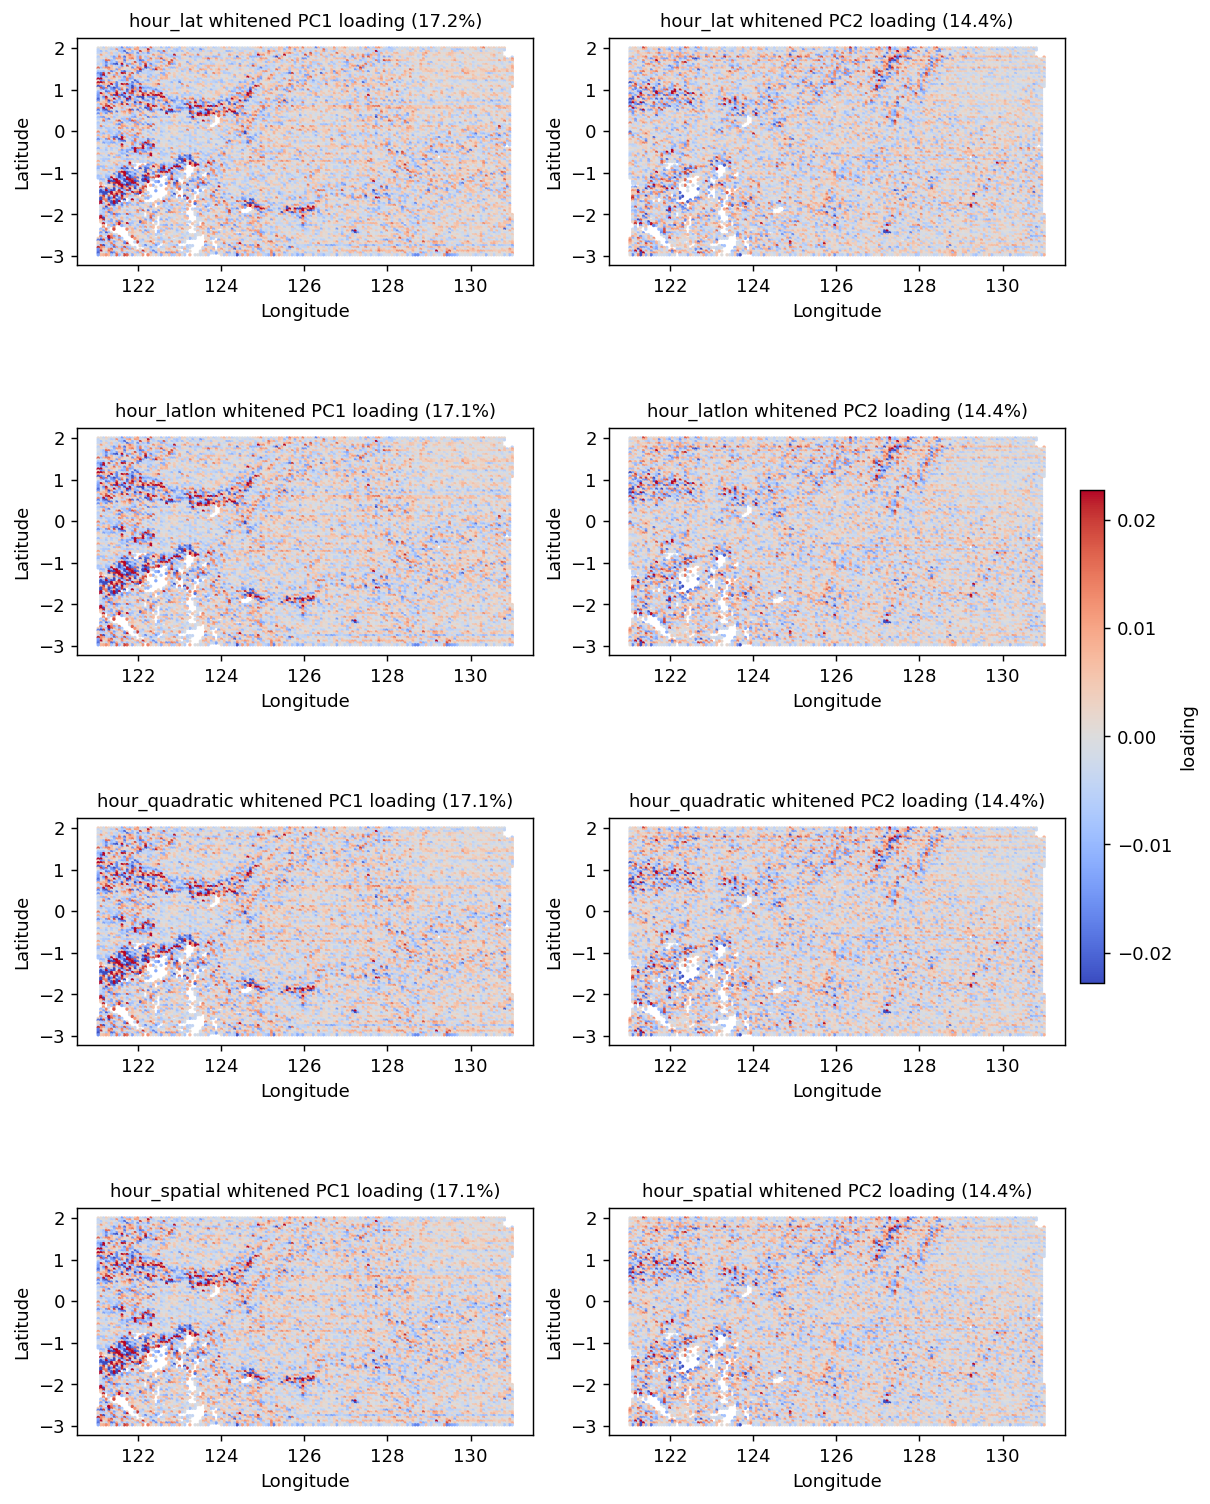

In [13]:
all_loading_values = []
for design in DESIGNS:
    svd = diagnostics[design]['svd']
    for k in range(min(2, svd['components'].shape[0])):
        all_loading_values.append(full_grid_values(svd['valid_mask'], svd['components'][k]))
loading_vmax = symmetric_quantile(np.concatenate([x[np.isfinite(x)] for x in all_loading_values]), q=0.99)

fig, axes = plt.subplots(len(DESIGNS), 2, figsize=(9.2, 3.0 * len(DESIGNS)), constrained_layout=True)
for r, design in enumerate(DESIGNS):
    svd = diagnostics[design]['svd']
    for c in range(2):
        ax = axes[r, c]
        if c < svd['components'].shape[0]:
            vals = full_grid_values(svd['valid_mask'], svd['components'][c])
            title = f'{design} whitened PC{c + 1} loading ({svd["explained"][c]:.1%})'
            sc = scatter_spatial(ax, vals, title, vmax=loading_vmax, size=3.5)
        else:
            ax.axis('off')
fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.025, pad=0.015, label='loading')
fig.savefig(OUT_DIR / f'{OUT_PREFIX}_pc_loading_maps.png')
plt.show()


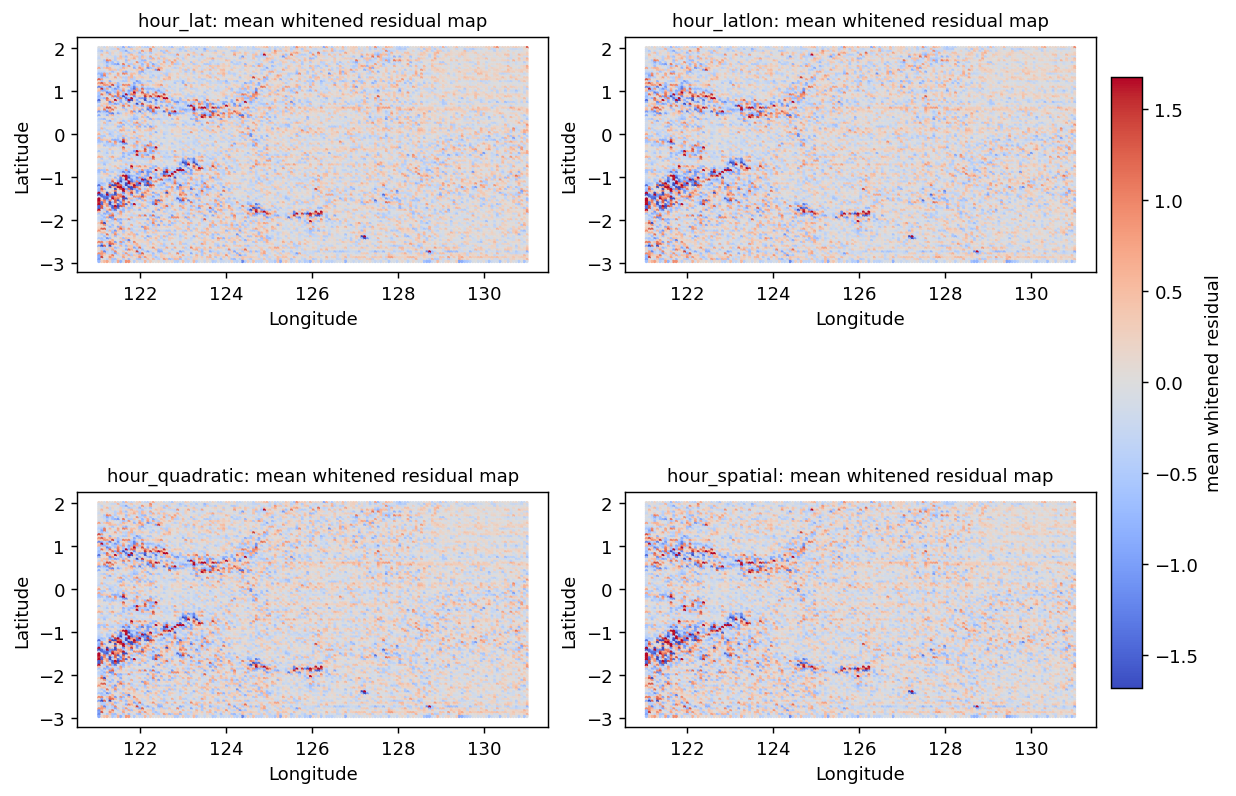

In [14]:
mean_maps = {design: np.nanmean(diagnostics[design]['whitened_matrix'], axis=0) for design in DESIGNS}
mean_vmax = symmetric_quantile(np.concatenate([v[np.isfinite(v)] for v in mean_maps.values()]), q=0.995)

fig, axes = plt.subplots(2, 2, figsize=(9.4, 7.0), constrained_layout=True)
for ax, design in zip(axes.ravel(), DESIGNS):
    sc = scatter_spatial(ax, mean_maps[design], f'{design}: mean whitened residual map', vmax=mean_vmax, size=3.5)
fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.03, pad=0.015, label='mean whitened residual')
fig.savefig(OUT_DIR / f'{OUT_PREFIX}_mean_whitened_residual_maps.png')
plt.show()


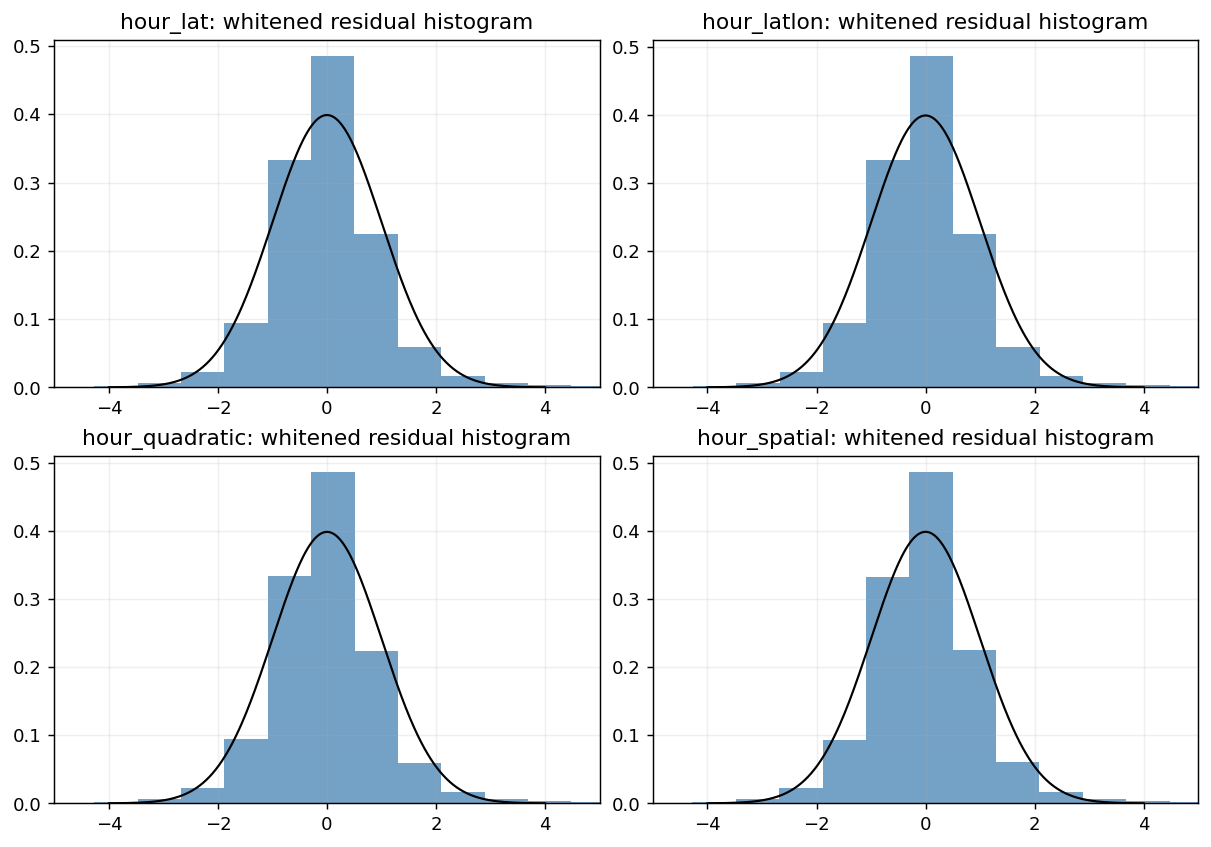

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(9.2, 6.4), constrained_layout=True)
for ax, design in zip(axes.ravel(), DESIGNS):
    vals = diagnostics[design]['whitened_matrix']
    vals = vals[np.isfinite(vals)]
    ax.hist(vals, bins=120, density=True, alpha=0.75, color='steelblue')
    xs = np.linspace(-4, 4, 401)
    ax.plot(xs, np.exp(-0.5 * xs**2) / np.sqrt(2 * np.pi), color='black', linewidth=1.2)
    ax.set_xlim(-5, 5)
    ax.set_title(f'{design}: whitened residual histogram')
    ax.grid(alpha=0.2)
fig.savefig(OUT_DIR / f'{OUT_PREFIX}_whitened_residual_histograms.png')
plt.show()


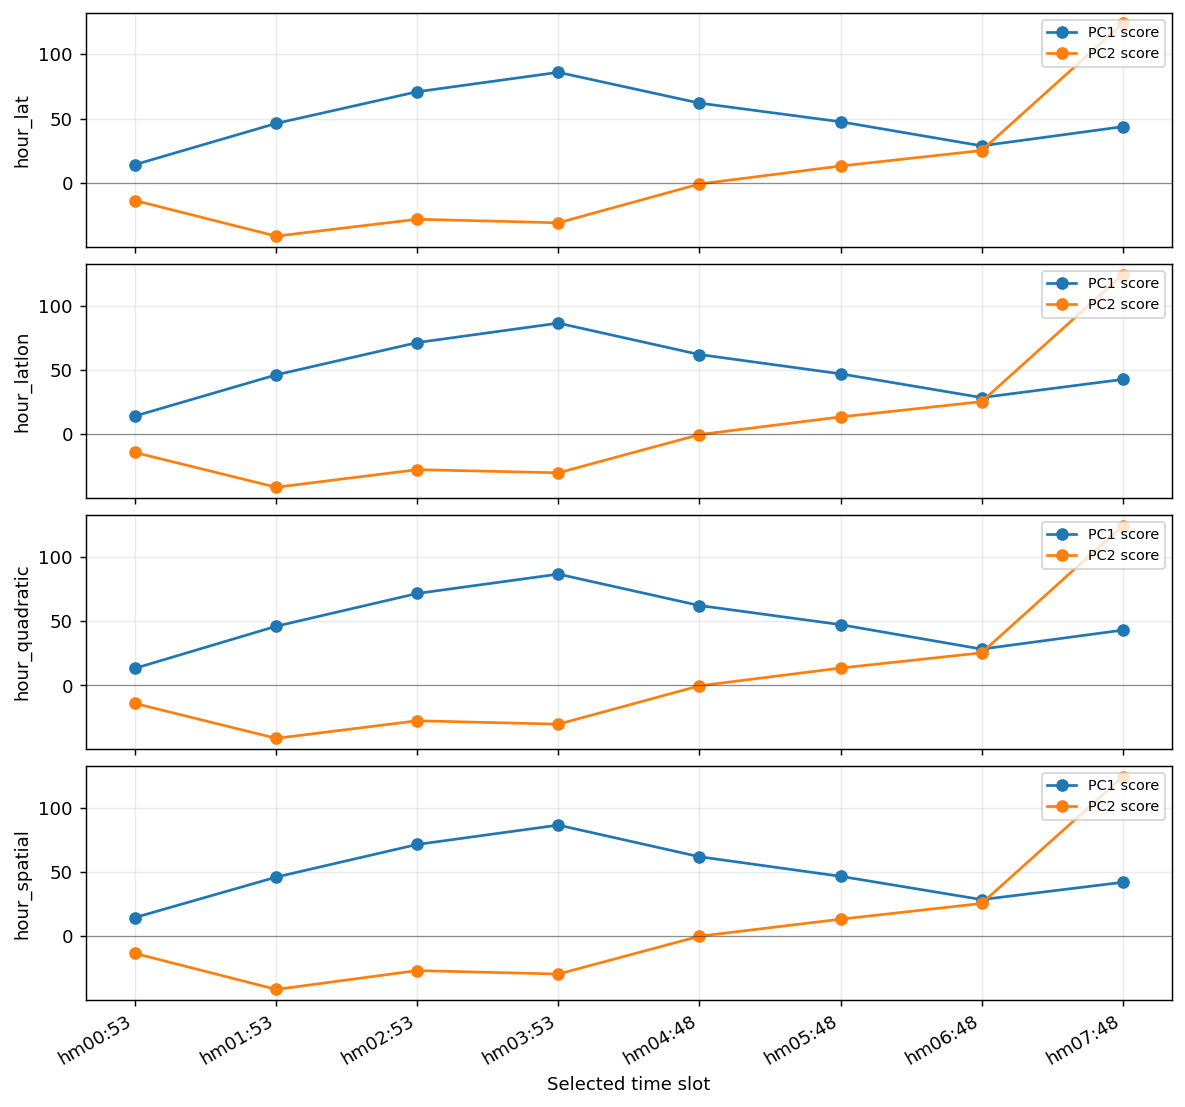

In [16]:
fig, axes = plt.subplots(len(DESIGNS), 1, figsize=(9, 2.1 * len(DESIGNS)), sharex=True, constrained_layout=True)
hour_labels = [k.split('_')[-1] for k in selected_key_map[DAY_IDX]]
for ax, design in zip(axes, DESIGNS):
    svd = diagnostics[design]['svd']
    x = np.arange(len(hour_labels))
    ax.plot(x, svd['scores'][:, 0], marker='o', label='PC1 score')
    if svd['scores'].shape[1] > 1:
        ax.plot(x, svd['scores'][:, 1], marker='o', label='PC2 score')
    ax.axhline(0, color='black', linewidth=0.7, alpha=0.4)
    ax.set_ylabel(design)
    ax.grid(alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xticks(np.arange(len(hour_labels)))
axes[-1].set_xticklabels(hour_labels, rotation=30, ha='right')
axes[-1].set_xlabel('Selected time slot')
fig.savefig(OUT_DIR / f'{OUT_PREFIX}_pc_time_scores.png')
plt.show()


## Compact readout

Use this table to compare raw residual PCA against the whitened diagnostic. If whitening works, PC1 share should be much less dominant than in raw residual PCA. If it remains dominant, the fitted covariance/advection/conditioning structure is still leaving organized residual structure.


In [17]:
readout_cols = [
    'design', 'n_features', 'fixed_cov_nll', 'wresid_mean', 'wresid_sd', 'wresid_rmse',
    'pc1_share', 'pc2_share', 'pc1_poly5_r2', 'mean_wresid_poly5_r2'
]
display(round_numeric_df(summary_df[readout_cols].sort_values(['pc1_share', 'pc1_poly5_r2'])))
print('saved outputs under:', OUT_DIR)


,design,n_features,fixed_cov_nll,wresid_mean,wresid_sd,wresid_rmse,pc1_share,pc2_share,pc1_poly5_r2,mean_wresid_poly5_r2
3,hour_spatial,24,1.0691,-0.0046,0.9994,0.9995,0.1711,0.1436,0.0015,0.0019
1,hour_latlon,10,1.0694,-0.0046,0.9998,0.9998,0.1712,0.1436,0.0026,0.0028
2,hour_quadratic,13,1.0691,-0.0042,0.9994,0.9994,0.1712,0.1437,0.0027,0.0028
0,hour_lat,9,1.0696,-0.0048,1.0000,1.0000,0.1716,0.1436,0.0047,0.0053


saved outputs under: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/space_time/vecchia_cluster_batch/diagnostics
